In [2]:
from pachner_traversal.utils import data_root
import pandas as pd
import matplotlib.pyplot as plt
import regina
import numpy as np
from pachner_traversal.data_io_dehydration import Dataset

In [11]:
obj = "det_alexander" # edge_degree_variance, det_alexander

res_path = (
    data_root
    / "results"
    / "sgd_models_dehydration"
    / "scalar_simple"
    / obj
    / "spheres_512emb_6block_4head_10tet"
)
processed_data_home = data_root / "input_data" / "dehydration" / "processed"
data_path = processed_data_home / "spheres_10.hdf5"

In [12]:
train_losses = pd.read_csv(res_path / "train_losses.csv", header=None, index_col=0)[1]
test_losses = pd.read_csv(res_path / "test_losses.csv", header=None, index_col=0)[1]

train_losses.index.name = None
test_losses.index.name = None

In [13]:
dataset = Dataset(data_path)

In [14]:
actual_edv = dataset.read_all_data(dset_name = obj)

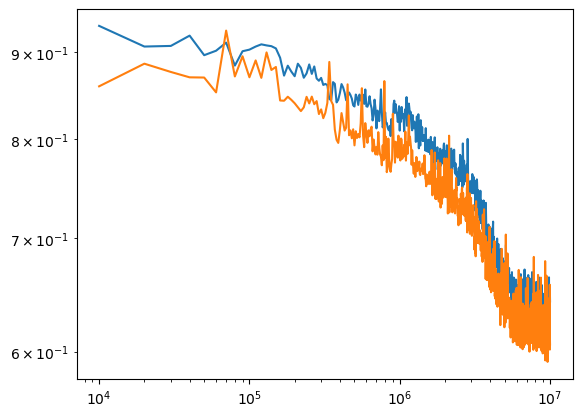

In [17]:
(train_losses / np.var(actual_edv)).plot()
(test_losses / np.var(actual_edv)).plot()

plt.loglog()
plt.show()